# Install and import libraries


In [ ]:
# !pip install scipy
# !pip install scikit-learn
# !pip install matplotlib
# !pip install seaborn
# !pip install imbalanced-learn


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from scipy.stats import linregress
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc, accuracy_score, f1_score


# Reading dataset into main_df for question 2

In [5]:
main_df = pd.DataFrame()

# Goes through each year from 1995 to 1999
for year in range(1995, 2000):
    file_name = f"dataset/{year}.csv"
    if os.path.exists(file_name): #will only run if the file exists
        df = pd.read_csv(file_name)

        # Data Cleaning
        df.drop_duplicates(inplace=True)
        #Remove negative values and Null values for time
        df = df[(df['ActualElapsedTime'] >= 0) | (df['ActualElapsedTime'].isna())] 
        df = df[(df['CRSElapsedTime'] >= 0) | (df['CRSElapsedTime'].isna())] 
        #Remove values greater than 2359 and Null values for 24 hour time
        df = df[(df['DepTime'] <= 2359) | (df['DepTime'].isna())]
        df = df[(df['ArrTime'] <= 2359) | (df['ArrTime'].isna())]                      

        # Append cleaned data to the main DataFrame
        main_df = pd.concat([main_df, df], ignore_index=True)

# Display the first few rows of the final DataFrame
print(main_df.head())


   Year  Month  DayofMonth  DayOfWeek  DepTime  CRSDepTime  ArrTime  \
0  1995      1           6          5    657.0         645    952.0   
1  1995      1           7          6    648.0         645    938.0   
2  1995      1           8          7    649.0         645    932.0   
3  1995      1           9          1    645.0         645    928.0   
4  1995      1          10          2    645.0         645    931.0   

   CRSArrTime UniqueCarrier  FlightNum  ... TaxiIn  TaxiOut  Cancelled  \
0         937            UA        482  ...      7       25          0   
1         937            UA        482  ...      5       17          0   
2         937            UA        482  ...      3       17          0   
3         937            UA        482  ...      3       16          0   
4         937            UA        482  ...      6       18          0   

   CancellationCode  Diverted  CarrierDelay WeatherDelay NASDelay  \
0               NaN         0           NaN          NaN   

Converting main_df column names to lowercase.

In [6]:
main_df.columns = main_df.columns.str.lower()
print(main_df.columns)

Index(['year', 'month', 'dayofmonth', 'dayofweek', 'deptime', 'crsdeptime',
       'arrtime', 'crsarrtime', 'uniquecarrier', 'flightnum', 'tailnum',
       'actualelapsedtime', 'crselapsedtime', 'airtime', 'arrdelay',
       'depdelay', 'origin', 'dest', 'distance', 'taxiin', 'taxiout',
       'cancelled', 'cancellationcode', 'diverted', 'carrierdelay',
       'weatherdelay', 'nasdelay', 'securitydelay', 'lateaircraftdelay'],
      dtype='object')


# Creating delay_df to answer part (a)

Taking columns 'year', 'month', 'dayofmonth', 'dayofweek', 'deptime', 'arrtime', 'arrdelay' into delay_df

In [10]:
delay_df = main_df[['year', 'month', 'dayofmonth', 'dayofweek', 'deptime', 'arrtime', 'arrdelay']].copy()
print(delay_df.head())

   year  month  dayofmonth  dayofweek  deptime  arrtime  arrdelay
0  1995      1           6          5    657.0    952.0      15.0
1  1995      1           7          6    648.0    938.0       1.0
2  1995      1           8          7    649.0    932.0      -5.0
3  1995      1           9          1    645.0    928.0      -9.0
4  1995      1          10          2    645.0    931.0      -6.0


In [11]:
#downloading delay_df as a csv
# delay_df.to_csv("dataset/delay_df.csv", index=False)


## Checking for Null values

In [12]:
print(delay_df.isna().sum())

year               0
month              0
dayofmonth         0
dayofweek          0
deptime       617022
arrtime       680419
arrdelay      680419
dtype: int64


## Summary of delay_df

In [13]:
delay_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 26992107 entries, 0 to 26992106
Data columns (total 7 columns):
 #   Column      Dtype  
---  ------      -----  
 0   year        int64  
 1   month       int64  
 2   dayofmonth  int64  
 3   dayofweek   int64  
 4   deptime     float64
 5   arrtime     float64
 6   arrdelay    float64
dtypes: float64(3), int64(4)
memory usage: 1.4 GB


Converting 'month' and 'dayofweek' into their names for easier identification


In [14]:
#Finding unique values for 'DayofMonth' and 'DayOfWeek'
print(delay_df['month'].unique())
print(delay_df['dayofweek'].unique())

[ 1  2  3  4  5  6  7  8  9 10 11 12]
[5 6 7 1 2 3 4]


In [ ]:
#creating a mapping dataframe for 'dayofweek'
day_of_week_mapping = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]

#Creating a mapping dataframe for 'month'  
month_mapping = ["January", "February", "March", "April", "May", "June", "July", "August", "September", "October", "November", "December"]

# Map numeric values to strings
delay_df['dayofweekstring'] = delay_df['dayofweek'].apply(lambda day: day_of_week_mapping[day - 1]) #-1 as python index starts from 0, therefore monday = 1 would be =0 in day_of_week_mapping
delay_df['monthstring'] = delay_df['month'].apply(lambda month: month_mapping[month - 1]) #similar to above explaination but for the different months

print(delay_df.head())


   year  month  dayofmonth  dayofweek  deptime  arrtime  arrdelay  \
0  1995      1           6          5    657.0    952.0      15.0   
1  1995      1           7          6    648.0    938.0       1.0   
2  1995      1           8          7    649.0    932.0      -5.0   
3  1995      1           9          1    645.0    928.0      -9.0   
4  1995      1          10          2    645.0    931.0      -6.0   

  dayofweekstring monthstring  
0          Friday     January  
1        Saturday     January  
2          Sunday     January  
3          Monday     January  
4         Tuesday     January  


Check "monthstring" and "dayofweekstring" for null values

In [16]:
print(delay_df['monthstring'].isna().sum())
print(delay_df['dayofweek'].isna().sum())

0
0


# Finding Delays

Based on US Department of Transportation (DOT), a flight is considered to be delayed when it's arrival time is 15 minutes later than its scheduled time. For part (a), I will be caterizing the delays by the following:


- on_time: less than 15mins delayed

- mild_delay: 15 to 60mins delayed

- moderate_delay: 60 to 180mins delayed 

- severe_delay: more than 180mins delayed 


These will be added to a new column "delay_classification" and will provide on insights that will help us find out what are the best times of the weeks to book an air ticket. 

Groupings the data in the dataset by on_time, mild_delay, moderate_delay and severe_delay based on arrival delay. 

In [17]:
def delay_classification(time):
    if pd.isna(time):
        return None #If the value is missing
    elif time <= 15: #Delay is less than 15 minutes
        return 'on_time'
    elif time < 60: #Delay is less than 60 minutes
        return 'mild_delay'
    elif time < 180: #Delay is less than 180 minutes
        return 'moderate_delay'
    else:
        return 'severe_delay' #Delay is greater than 180 minutes

delay_df['delay_classification'] = delay_df['arrdelay'].apply(delay_classification)
print(delay_df.head())

    

   year  month  dayofmonth  dayofweek  deptime  arrtime  arrdelay  \
0  1995      1           6          5    657.0    952.0      15.0   
1  1995      1           7          6    648.0    938.0       1.0   
2  1995      1           8          7    649.0    932.0      -5.0   
3  1995      1           9          1    645.0    928.0      -9.0   
4  1995      1          10          2    645.0    931.0      -6.0   

  dayofweekstring monthstring delay_classification  
0          Friday     January              on_time  
1        Saturday     January              on_time  
2          Sunday     January              on_time  
3          Monday     January              on_time  
4         Tuesday     January              on_time  


Removing missing values in delay_classification

In [ ]:
delay_df.dropna(subset=['delay_classification'], inplace=True)

Checking for missing values in delay_classification

In [ ]:
print(delay_df['delay_classification'].isna().sum())

0


Checking delay_classification distribution

In [20]:
delay_df['delay_classification'].value_counts()

delay_classification
on_time           21020262
mild_delay         4056369
moderate_delay     1119831
severe_delay        115226
Name: count, dtype: int64

# Classifying time of day

We will be grouping the time of day as following:

- Midnight: 0000 to 0559

- Morning: 0600 to 1159

- Afternoon: 1200 to 1759

- Night: 1800 to 2359 

These will be added to a new column "time_of_day" and will provide insights on when is the best time to fly to minimise delays. We used departure time as the timing on tickets are usually the departure time of flights.


In [21]:
# Creating a function for time of day classification
def time_of_day(time):
    if time <= 559:
        return 'Midnight'
    elif time <= 1159:
        return 'Morning'
    elif time <= 1759:
        return 'Afternoon'
    else:
        return 'Night'

delay_df['time_of_day'] = delay_df['deptime'].apply(time_of_day)

print(delay_df.head())

   year  month  dayofmonth  dayofweek  deptime  arrtime  arrdelay  \
0  1995      1           6          5    657.0    952.0      15.0   
1  1995      1           7          6    648.0    938.0       1.0   
2  1995      1           8          7    649.0    932.0      -5.0   
3  1995      1           9          1    645.0    928.0      -9.0   
4  1995      1          10          2    645.0    931.0      -6.0   

  dayofweekstring monthstring delay_classification time_of_day  
0          Friday     January              on_time     Morning  
1        Saturday     January              on_time     Morning  
2          Sunday     January              on_time     Morning  
3          Monday     January              on_time     Morning  
4         Tuesday     January              on_time     Morning  


Checking for missing values in time_of_day

In [ ]:
print(delay_df['time_of_day'].isna().sum())

0


Replacing Month and Days with their respective names (string)

In [24]:
# Creating a mapping list for days of a week and applying it to delay_df
days = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
delay_df['dayofweekstring'] = delay_df['dayofweek'].apply(lambda day: days[day - 1]) # -1 as python index starts from 0, therefore monday = 1 would be in position 0 in days

# Creating a mapping list for months
months = ["January", "February", "March", "April", "May", "June", "July", "August", "September", "October", "November", "December"]
delay_df['monthstring'] = delay_df['month'].apply(lambda month: months[month - 1]) # -1 as python index starts from 0, therefore January = 1 would be in position 0 in months

#Finalised main data frame
print(delay_df.head())

   year  month  dayofmonth  dayofweek  deptime  arrtime  arrdelay  \
0  1995      1           6          5    657.0    952.0      15.0   
1  1995      1           7          6    648.0    938.0       1.0   
2  1995      1           8          7    649.0    932.0      -5.0   
3  1995      1           9          1    645.0    928.0      -9.0   
4  1995      1          10          2    645.0    931.0      -6.0   

  dayofweekstring monthstring delay_classification time_of_day  
0          Friday     January              on_time     Morning  
1        Saturday     January              on_time     Morning  
2          Sunday     January              on_time     Morning  
3          Monday     January              on_time     Morning  
4         Tuesday     January              on_time     Morning  


Checking for null values for before using dataframe to answer 2(a)

In [25]:
print(delay_df.isnull().sum())

year                    0
month                   0
dayofmonth              0
dayofweek               0
deptime                 0
arrtime                 0
arrdelay                0
dayofweekstring         0
monthstring             0
delay_classification    0
time_of_day             0
dtype: int64


Renaming dataframe to final_delay_df

In [27]:
final_delay_df = delay_df.copy()

In [ ]:
# Downloading final data frame
# final_delay_df.to_csv('dataset/final_delay_df.csv', index=False)

In [29]:
print(final_delay_df.head())

   year  month  dayofmonth  dayofweek  deptime  arrtime  arrdelay  \
0  1995      1           6          5    657.0    952.0      15.0   
1  1995      1           7          6    648.0    938.0       1.0   
2  1995      1           8          7    649.0    932.0      -5.0   
3  1995      1           9          1    645.0    928.0      -9.0   
4  1995      1          10          2    645.0    931.0      -6.0   

  dayofweekstring monthstring delay_classification time_of_day  
0          Friday     January              on_time     Morning  
1        Saturday     January              on_time     Morning  
2          Sunday     January              on_time     Morning  
3          Monday     January              on_time     Morning  
4         Tuesday     January              on_time     Morning  


# 2(a) Finding the best time to fly

In order to find the best time to fly to minimise delay, we will be grouping delays by 'time_of_day' and 'delay_classification" and finding the count of each.

In [30]:
grouped_time_df = final_delay_df.value_counts(['time_of_day', 'delay_classification']).reset_index(name='count')
print(grouped_time_df)

   time_of_day delay_classification    count
0      Morning              on_time  8620835
1    Afternoon              on_time  7789092
2        Night              on_time  4304523
3    Afternoon           mild_delay  1666018
4        Night           mild_delay  1213586
5      Morning           mild_delay  1138166
6        Night       moderate_delay   511192
7    Afternoon       moderate_delay   406826
8     Midnight              on_time   305812
9      Morning       moderate_delay   177445
10       Night         severe_delay    60344
11    Midnight           mild_delay    38599
12   Afternoon         severe_delay    32898
13    Midnight       moderate_delay    24368
14    Midnight         severe_delay    12704
15     Morning         severe_delay     9280


To make sense of the data from grouped_by_day_df, we will be finding the percentage of each row.

In [31]:
# calculating the total count of delays for each time of day
total_time_of_day = grouped_time_df.groupby('time_of_day')['count'].transform('sum')

# Compute percentage for each row
grouped_time_df['percentage'] = (grouped_time_df['count'] / total_time_of_day) * 100

# Round to 2 decimal places for readability
grouped_time_df['percentage'] = grouped_time_df['percentage'].round(2)

# Display the result
print(grouped_time_df)

   time_of_day delay_classification    count  percentage
0      Morning              on_time  8620835       86.68
1    Afternoon              on_time  7789092       78.72
2        Night              on_time  4304523       70.69
3    Afternoon           mild_delay  1666018       16.84
4        Night           mild_delay  1213586       19.93
5      Morning           mild_delay  1138166       11.44
6        Night       moderate_delay   511192        8.39
7    Afternoon       moderate_delay   406826        4.11
8     Midnight              on_time   305812       80.16
9      Morning       moderate_delay   177445        1.78
10       Night         severe_delay    60344        0.99
11    Midnight           mild_delay    38599       10.12
12   Afternoon         severe_delay    32898        0.33
13    Midnight       moderate_delay    24368        6.39
14    Midnight         severe_delay    12704        3.33
15     Morning         severe_delay     9280        0.09


Plotting a pie chart that shows the proportion of each delay classification. 

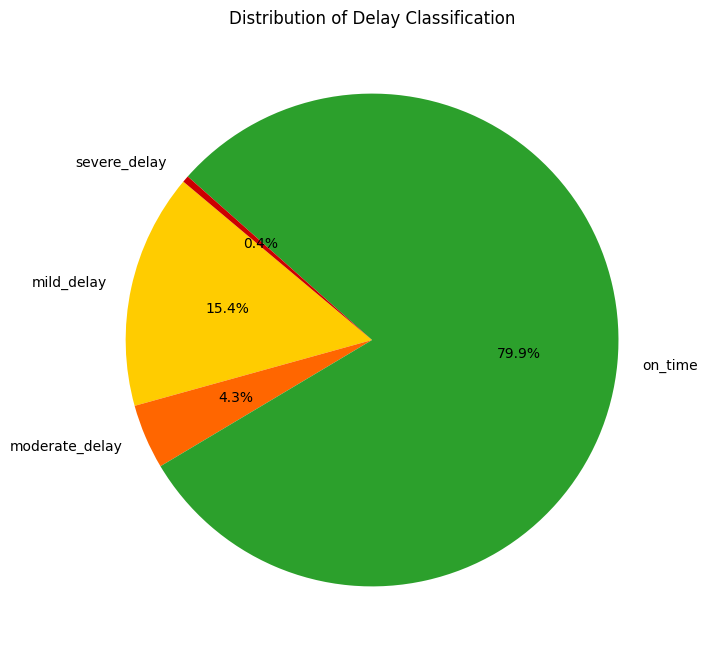

In [32]:
# Aggregate the count for each delay classification
delay_counts = grouped_time_df.groupby("delay_classification")["count"].sum()

# Define colors for delay classifications (from green to red)
color_map = {
    "on_time": "#2ca02c",  # Green
    "mild_delay": "#ffcc00",  # Yellow
    "moderate_delay": "#ff6600",  # Orange
    "severe_delay": "#cc0000"  # Red
}

# Create a pie chart
plt.figure(figsize=(8, 8))
plt.pie(
    delay_counts, 
    labels=delay_counts.index, 
    autopct='%1.1f%%', 
    startangle=140, 
    colors=[color_map[label] for label in delay_counts.index]  # Assign colors dynamically
)

# Title
plt.title("Distribution of Delay Classification")

# Show the plot
plt.show()


Plotting a bar chart that shows percentage of delays against time of day.

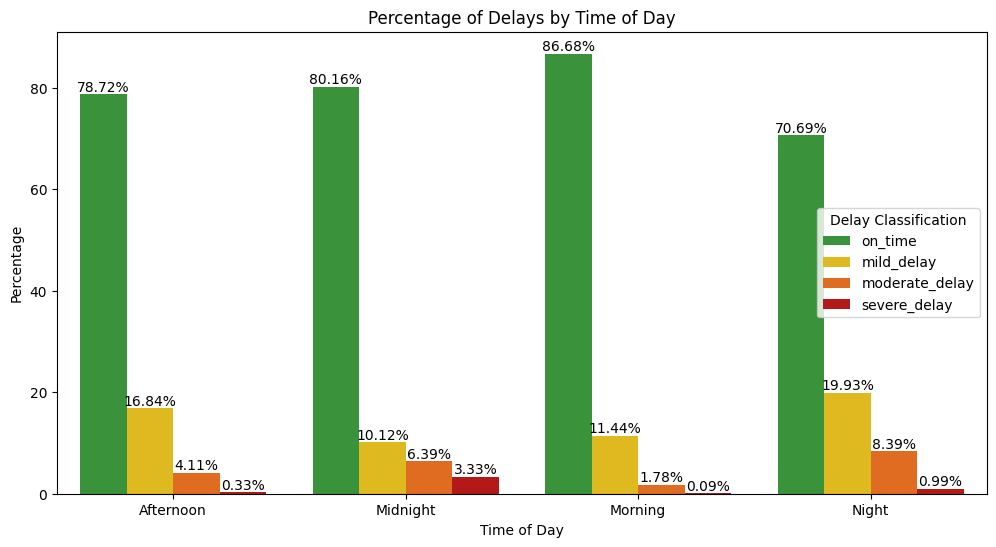

In [33]:
# Define colors for delay classifications (from green to red)
color_map = {
    "on_time": "#2ca02c",  # Green
    "mild_delay": "#ffcc00",  # Yellow
    "moderate_delay": "#ff6600",  # Orange
    "severe_delay": "#cc0000"  # Red
}

# Sort the dataframe so that within each Time_of_Day, bars are sorted in decreasing order of Weighted_Percentage
grouped_time_df = grouped_time_df.sort_values(
    by=["time_of_day", "percentage"], 
    ascending=[True, False]
)

# Set figure size
plt.figure(figsize=(12, 6))

# Create the bar chart
bars = sns.barplot(
    data=grouped_time_df, 
    x="time_of_day", 
    y="percentage", 
    hue="delay_classification",
    palette=color_map
)

# Add value labels on top of bars
for bar in bars.patches:
    height = bar.get_height()
    if height > 0:  # Only label bars with a positive height
        bars.annotate(f'{height:.2f}%', 
                      (bar.get_x() + bar.get_width() / 2, height), 
                      ha='center', va='bottom', fontsize=10, color='black')

# Labels and title
plt.xlabel("Time of Day")
plt.ylabel("Percentage")
plt.title("Percentage of Delays by Time of Day")

# Show the legend
plt.legend(title="Delay Classification")

# Display the plot
plt.show()

Based on the graph above, morning flights have the most flights that are on time at 86.68% of flights, while night flights tend to be delayed more often with only 70.69% of flights being on time. Based on the visuals above, I would recommend booking morning flights and avoiding booking night flights.


# Finding the best day of the week to book flight tickets.

 In order to find the best day of the week to book a plane ticket, we will be grouping delays by "dayofweekstring" and 'delay_classification" and finding the count of each.

In [34]:
print(final_delay_df)

          year  month  dayofmonth  dayofweek  deptime  arrtime  arrdelay  \
0         1995      1           6          5    657.0    952.0      15.0   
1         1995      1           7          6    648.0    938.0       1.0   
2         1995      1           8          7    649.0    932.0      -5.0   
3         1995      1           9          1    645.0    928.0      -9.0   
4         1995      1          10          2    645.0    931.0      -6.0   
...        ...    ...         ...        ...      ...      ...       ...   
26992102  1999     12          16          4   1910.0   2112.0      -5.0   
26992103  1999     12          17          5   1909.0   2111.0      -6.0   
26992104  1999     12          18          6   1907.0   2103.0     -14.0   
26992105  1999     12          19          7   1907.0   2114.0      -3.0   
26992106  1999     12          20          1   1905.0   2127.0      10.0   

         dayofweekstring monthstring delay_classification time_of_day  
0              

In [35]:
grouped_day_df = final_delay_df.value_counts(['dayofweekstring', 'delay_classification']).reset_index(name='count')
print(grouped_day_df)

   dayofweekstring delay_classification    count
0          Tuesday              on_time  3136090
1           Monday              on_time  3119170
2        Wednesday              on_time  3073646
3         Thursday              on_time  2975601
4           Sunday              on_time  2957192
5           Friday              on_time  2921914
6         Saturday              on_time  2836649
7           Friday           mild_delay   692721
8         Thursday           mild_delay   655723
9        Wednesday           mild_delay   591930
10          Monday           mild_delay   559775
11          Sunday           mild_delay   552699
12         Tuesday           mild_delay   548799
13        Saturday           mild_delay   454722
14          Friday       moderate_delay   201149
15        Thursday       moderate_delay   184129
16       Wednesday       moderate_delay   168310
17          Monday       moderate_delay   152908
18         Tuesday       moderate_delay   151306
19          Sunday  

In [36]:
# calculating the total count of delays for each day of the week
total_day = grouped_day_df.groupby('dayofweekstring')['count'].transform('sum')

# Compute percentage for each row
grouped_day_df['percentage'] = (grouped_day_df['count'] / total_day) * 100

# Round to 2 decimal places for readability
grouped_day_df['percentage'] = grouped_day_df['percentage'].round(2)

# Display the result
print(grouped_day_df)

   dayofweekstring delay_classification    count  percentage
0          Tuesday              on_time  3136090       81.45
1           Monday              on_time  3119170       81.07
2        Wednesday              on_time  3073646       79.83
3         Thursday              on_time  2975601       77.58
4           Sunday              on_time  2957192       80.54
5           Friday              on_time  2921914       76.12
6         Saturday              on_time  2836649       82.98
7           Friday           mild_delay   692721       18.05
8         Thursday           mild_delay   655723       17.10
9        Wednesday           mild_delay   591930       15.37
10          Monday           mild_delay   559775       14.55
11          Sunday           mild_delay   552699       15.05
12         Tuesday           mild_delay   548799       14.25
13        Saturday           mild_delay   454722       13.30
14          Friday       moderate_delay   201149        5.24
15        Thursday      

Plotting a bar chart that shows percentage of delays against day of the week.

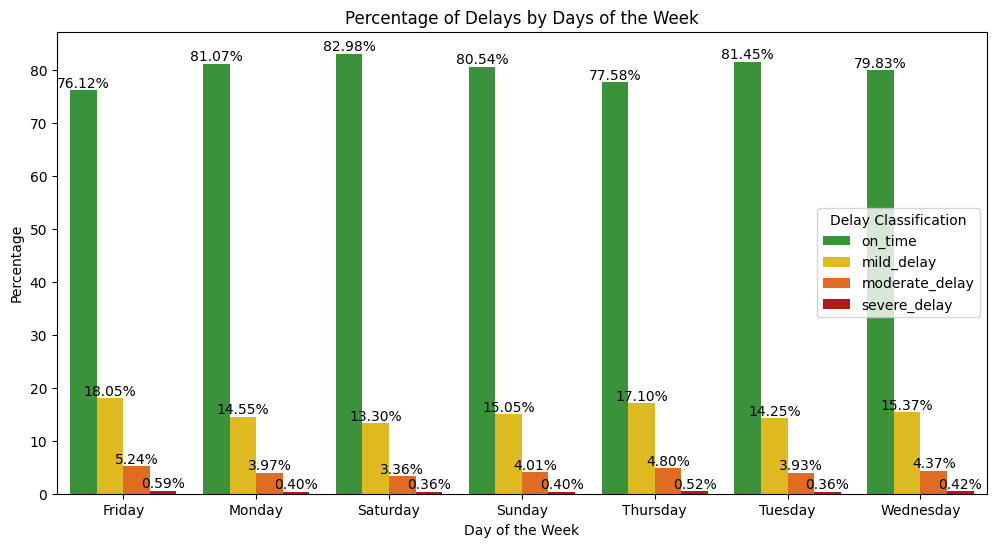

In [ ]:
# Define colors for delay classifications (from green to red)
color_map = {
    "on_time": "#2ca02c",  # Green
    "mild_delay": "#ffcc00",  # Yellow
    "moderate_delay": "#ff6600",  # Orange
    "severe_delay": "#cc0000"  # Red
}

# Sort the dataframe so that within each Time_of_Day, bars are sorted in decreasing order of Weighted_Percentage
grouped_day_df = grouped_day_df.sort_values(
    by=["dayofweekstring", "percentage"], 
    ascending=[True, False]
)

# Set figure size
plt.figure(figsize=(12, 6))

# Create the bar chart
bars = sns.barplot(
    data=grouped_day_df, 
    x="dayofweekstring", 
    y="percentage", 
    hue="delay_classification",
    palette=color_map
)

# Add value labels on top of bars
for bar in bars.patches:
    height = bar.get_height()
    if height > 0:  # Only label bars with a positive height
        bars.annotate(f'{height:.2f}%', 
                      (bar.get_x() + bar.get_width() / 2, height), 
                      ha='center', va='bottom', fontsize=10, color='black')

# Labels and title
plt.xlabel("Day of the Week")
plt.ylabel("Percentage")
plt.title("Percentage of Delays by Days of the Week")

# Show the legend
plt.legend(title="Delay Classification")

# Display the plot
plt.show()

Based on the graph above, Saturdays has the highest percentage of flights that are on time at 82.98% while Fridays has the least percentage of flights that are on time at 76.12%. 

Based on the visual above, the best day to fly is Saturday. 

# Finding best days of the week to fly for each year

In [38]:
# Group by year and day of week, calculate average arrival delay
grouped_days = final_delay_df.groupby(['year', 'dayofweekstring'])['arrdelay'].mean().reset_index()

# For each year, find the day with the minimum average delay
best_days = grouped_days.loc[grouped_days.groupby('year')['arrdelay'].idxmin()]

# Print results for each year
for year in best_days['year'].unique():
    row = best_days[best_days['year'] == year].iloc[0]
    print(f"In {int(row['year'])}, the best day to fly was {row['dayofweekstring']} with an average arrival delay of {row['arrdelay']:.2f} minutes.")

In 1995, the best day to fly was Saturday with an average arrival delay of 5.32 minutes.
In 1996, the best day to fly was Saturday with an average arrival delay of 6.86 minutes.
In 1997, the best day to fly was Saturday with an average arrival delay of 5.41 minutes.
In 1998, the best day to fly was Saturday with an average arrival delay of 3.56 minutes.
In 1999, the best day to fly was Saturday with an average arrival delay of 5.34 minutes.


# Finding best time of day to fly for each year

In [39]:
# Group by year and time of day, calculate average arrival delay
grouped_time = final_delay_df.groupby(['year', 'time_of_day'])['arrdelay'].mean().reset_index()

# For each year, find the time of day with the lowest average delay
best_times = grouped_time.loc[grouped_time.groupby('year')['arrdelay'].idxmin()]

# Print results for each year
for year in best_times['year'].unique():
    row = best_times[best_times['year'] == year].iloc[0]
    print(f"In {int(row['year'])}, the best time of day to fly was {row['time_of_day']} with an average arrival delay of {row['arrdelay']:.2f} minutes.")

In 1995, the best time of day to fly was Morning with an average arrival delay of 2.70 minutes.
In 1996, the best time of day to fly was Morning with an average arrival delay of 4.32 minutes.
In 1997, the best time of day to fly was Morning with an average arrival delay of 3.04 minutes.
In 1998, the best time of day to fly was Morning with an average arrival delay of 2.23 minutes.
In 1999, the best time of day to fly was Morning with an average arrival delay of 2.18 minutes.


# Part 2(b) Evaluate wether older planes suffer more delays on a year-to-year basis.



Loading dataset

In [7]:
planes_data_df = pd.read_csv('dataset/plane-data.csv')
print(planes_data_df)

     tailnum                 type                   manufacturer  issue_date  \
0     N050AA                  NaN                            NaN         NaN   
1     N051AA                  NaN                            NaN         NaN   
2     N052AA                  NaN                            NaN         NaN   
3     N054AA                  NaN                            NaN         NaN   
4     N055AA                  NaN                            NaN         NaN   
...      ...                  ...                            ...         ...   
5024  N997DL          Corporation  MCDONNELL DOUGLAS AIRCRAFT CO  03/11/1992   
5025  N998AT          Corporation                         BOEING  01/23/2003   
5026  N998DL          Corporation  MCDONNELL DOUGLAS CORPORATION  04/02/1992   
5027  N999CA  Foreign Corporation                       CANADAIR  07/09/2008   
5028  N999DN          Corporation  MCDONNELL DOUGLAS CORPORATION  04/02/1992   

            model status            air

In [8]:
print(planes_data_df.isnull().sum())
print(planes_data_df.info())

tailnum            0
type             549
manufacturer     549
issue_date       550
model            549
status           549
aircraft_type    549
engine_type      552
year             694
dtype: int64
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5029 entries, 0 to 5028
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   tailnum        5029 non-null   object 
 1   type           4480 non-null   object 
 2   manufacturer   4480 non-null   object 
 3   issue_date     4479 non-null   object 
 4   model          4480 non-null   object 
 5   status         4480 non-null   object 
 6   aircraft_type  4480 non-null   object 
 7   engine_type    4477 non-null   object 
 8   year           4335 non-null   float64
dtypes: float64(1), object(8)
memory usage: 353.7+ KB
None


Unique column names for planes_data_df and main_df 

In [9]:
print(planes_data_df.columns)
print(main_df.columns)

Index(['tailnum', 'type', 'manufacturer', 'issue_date', 'model', 'status',
       'aircraft_type', 'engine_type', 'year'],
      dtype='object')
Index(['year', 'month', 'dayofmonth', 'dayofweek', 'deptime', 'crsdeptime',
       'arrtime', 'crsarrtime', 'uniquecarrier', 'flightnum', 'tailnum',
       'actualelapsedtime', 'crselapsedtime', 'airtime', 'arrdelay',
       'depdelay', 'origin', 'dest', 'distance', 'taxiin', 'taxiout',
       'cancelled', 'cancellationcode', 'diverted', 'carrierdelay',
       'weatherdelay', 'nasdelay', 'securitydelay', 'lateaircraftdelay'],
      dtype='object')


Merging planes_data_df and main_df using the column 'tailnum' 

In [10]:
merged_df = pd.merge(main_df, planes_data_df, how='inner', left_on='tailnum', right_on='tailnum', suffixes=('main_df', 'planes_data_df'))

In [11]:
print(merged_df.head())

   yearmain_df  month  dayofmonth  dayofweek  deptime  crsdeptime  arrtime  \
0         1995      1           2          1   1148.0        1145   1428.0   
1         1995      1           3          2   1209.0        1145   1450.0   
2         1995      1           7          6   1200.0        1150   1447.0   
3         1995      1           8          7   1151.0        1150   1435.0   
4         1995      1           9          1   1154.0        1150   1433.0   

   crsarrtime uniquecarrier  flightnum  ... securitydelay  lateaircraftdelay  \
0        1435            UA       1845  ...           NaN                NaN   
1        1435            UA       1845  ...           NaN                NaN   
2        1440            UA       1845  ...           NaN                NaN   
3        1440            UA       1845  ...           NaN                NaN   
4        1440            UA       1845  ...           NaN                NaN   

          type  manufacturer  issue_date    model 

In [12]:
print(merged_df.columns)

Index(['yearmain_df', 'month', 'dayofmonth', 'dayofweek', 'deptime',
       'crsdeptime', 'arrtime', 'crsarrtime', 'uniquecarrier', 'flightnum',
       'tailnum', 'actualelapsedtime', 'crselapsedtime', 'airtime', 'arrdelay',
       'depdelay', 'origin', 'dest', 'distance', 'taxiin', 'taxiout',
       'cancelled', 'cancellationcode', 'diverted', 'carrierdelay',
       'weatherdelay', 'nasdelay', 'securitydelay', 'lateaircraftdelay',
       'type', 'manufacturer', 'issue_date', 'model', 'status',
       'aircraft_type', 'engine_type', 'yearplanes_data_df'],
      dtype='object')


In [46]:
merged_df

,yearmain_df,month,dayofmonth,dayofweek,deptime,crsdeptime,arrtime,crsarrtime,uniquecarrier,flightnum,...,securitydelay,lateaircraftdelay,type,manufacturer,issue_date,model,status,aircraft_type,engine_type,yearplanes_data_df
0,1995,1,2,1,1148.0,1145,1428.0,1435,UA,1845,...,NaN,NaN,Corporation,BOEING,04/10/1992,737-522,Valid,Fixed Wing Multi-Engine,Turbo-Fan,1992.0
1,1995,1,3,2,1209.0,1145,1450.0,1435,UA,1845,...,NaN,NaN,Corporation,BOEING,01/06/1992,737-522,Valid,Fixed Wing Multi-Engine,Turbo-Fan,1991.0
2,1995,1,7,6,1200.0,1150,1447.0,1440,UA,1845,...,NaN,NaN,Corporation,BOEING,05/27/1992,737-522,Valid,Fixed Wing Multi-Engine,Turbo-Fan,1992.0
3,1995,1,8,7,1151.0,1150,1435.0,1440,UA,1845,...,NaN,NaN,Corporation,BOEING,03/27/1987,737-322,Valid,Fixed Wing Multi-Engine,Turbo-Fan,1987.0
4,1995,1,9,1,1154.0,1150,1433.0,1440,UA,1845,...,NaN,NaN,Corporation,BOEING,08/07/1991,737-522,Valid,Fixed Wing Multi-Engine,Turbo-Fan,1991.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9748385,1999,12,12,7,1244.0,1246,1454.0,1453,AA,809,...,NaN,NaN,Corporation,MCDONNELL DOUGLAS,08/23/1991,DC-9-82(MD-82),Valid,Fixed Wing Multi-Engine,Turbo-Fan,1991.0
9748386,1999,12,13,1,1244.0,1246,1457.0,1453,AA,809,...,NaN,NaN,Corporation,MCDONNELL DOUGLAS,07/09/1998,DC-9-82(MD-82),Valid,Fixed Wing Multi-Engine,Turbo-Fan,1987.0
9748387,1999,12,1,3,940.0,941,1125.0,1154,AA,1087,...,NaN,NaN,Corporation,MCDONNELL DOUGLAS,06/27/1986,DC-9-82(MD-82),Valid,Fixed Wing Multi-Engine,Turbo-Fan,1986.0
9748388,1999,12,5,7,937.0,943,1158.0,1153,AA,1087,...,NaN,NaN,Corporation,MCDONNELL DOUGLAS,10/31/1989,DC-9-82(MD-82),Valid,Fixed Wing Multi-Engine,Turbo-Fan,1989.0


Checking for null values in merged_df

In [13]:
print(merged_df.isnull().sum())

yearmain_df                 0
month                       0
dayofmonth                  0
dayofweek                   0
deptime                 83628
crsdeptime                  0
arrtime                106632
crsarrtime                  0
uniquecarrier               0
flightnum                   0
tailnum                     0
actualelapsedtime      106632
crselapsedtime           1120
airtime                100992
arrdelay               106632
depdelay                83628
origin                      0
dest                        0
distance                 1500
taxiin                      0
taxiout                     0
cancelled                   0
cancellationcode      9748390
diverted                    0
carrierdelay          9748390
weatherdelay          9748390
nasdelay              9748390
securitydelay         9748390
lateaircraftdelay     9748390
type                   723044
manufacturer           723044
issue_date             723314
model                  723044
status    

We will be choosing and renaming some columns to answer the second question.

Same as part (a), we will be using arrival delay only as the US Department of Transportation (DOT) defines delay as arrival delay.

In [14]:
age_df = merged_df[['yearmain_df', 'flightnum', 'tailnum', 'arrdelay', 'yearplanes_data_df']].copy()
print(age_df.head())

   yearmain_df  flightnum tailnum  arrdelay  yearplanes_data_df
0         1995       1845  N929UA      -7.0              1992.0
1         1995       1845  N922UA      15.0              1991.0
2         1995       1845  N933UA       7.0              1992.0
3         1995       1845  N308UA      -5.0              1987.0
4         1995       1845  N913UA      -7.0              1991.0


Rename yearmain_df to current_year and yearplanes_data_df to plane_year

In [15]:
age_df.rename(columns={'yearmain_df': 'current_year', 'yearplanes_data_df': 'plane_year'}, inplace=True)
print(age_df.head())

   current_year  flightnum tailnum  arrdelay  plane_year
0          1995       1845  N929UA      -7.0      1992.0
1          1995       1845  N922UA      15.0      1991.0
2          1995       1845  N933UA       7.0      1992.0
3          1995       1845  N308UA      -5.0      1987.0
4          1995       1845  N913UA      -7.0      1991.0


Removing null values from plane_year

In [16]:
age_df = age_df.dropna(subset=['plane_year'])
print(age_df.isnull().sum())

current_year         0
flightnum            0
tailnum              0
arrdelay        102730
plane_year           0
dtype: int64


In [51]:
print(age_df.info())

<class 'pandas.core.frame.DataFrame'>
Index: 8984362 entries, 0 to 9748389
Data columns (total 5 columns):
 #   Column        Dtype  
---  ------        -----  
 0   current_year  int64  
 1   flightnum     int64  
 2   tailnum       object 
 3   arrdelay      float64
 4   plane_year    float64
dtypes: float64(2), int64(2), object(1)
memory usage: 411.3+ MB
None


Converting plane_year to integer for calculating age of plane

In [17]:
#converting plane_year to integer
age_df['plane_year'] = age_df['plane_year'].astype(int)
age_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 8984362 entries, 0 to 9748389
Data columns (total 5 columns):
 #   Column        Dtype  
---  ------        -----  
 0   current_year  int64  
 1   flightnum     int64  
 2   tailnum       object 
 3   arrdelay      float64
 4   plane_year    int64  
dtypes: float64(1), int64(3), object(1)
memory usage: 411.3+ MB


To find the age of a plane, we will be taking current year minus the issue date.

In [23]:
age_df['plane_age'] = age_df['current_year'] - age_df['plane_year']
print(age_df.head())

   current_year  flightnum tailnum  arrdelay  plane_year  plane_age
0          1995       1845  N929UA      -7.0        1992          3
1          1995       1845  N922UA      15.0        1991          4
2          1995       1845  N933UA       7.0        1992          3
3          1995       1845  N308UA      -5.0        1987          8
4          1995       1845  N913UA      -7.0        1991          4


In [19]:
print(age_df.isnull().sum())

current_year         0
flightnum            0
tailnum              0
arrdelay        102730
plane_year           0
plane_age            0
dtype: int64


Removing null values for arrival delay

In [22]:
age_df = age_df.dropna(subset=['arrdelay'])
print(age_df.isnull().sum())

current_year    0
flightnum       0
tailnum         0
arrdelay        0
plane_year      0
plane_age       0
dtype: int64


We will now be grouping the dataset by the plane's tail number to get the average delays for each model of plane.

In [21]:
# Group by 'tailnum' to calculate average delay for the plane age
plane_summary_df = age_df.groupby('tailnum', as_index=False).agg(
    average_arrdelay=('arrdelay', 'mean'),  # Average arrival delay
    plane_age=('plane_age', 'first')  # Grouping by the first plane age for each tailnum as the rest would be the same
)

print(plane_summary_df.head())


  tailnum  average_arrdelay  plane_age
0  N102UW         10.036585          1
1  N10323          6.577956          9
2  N104UA         11.612069          0
3  N104UW         13.953317          0
4  N105UA         18.342037          1


Remove plane age that are less than 0

In [24]:
plane_summary_df = plane_summary_df[plane_summary_df['plane_age'] >= 0]
print(plane_summary_df.head())

  tailnum  average_arrdelay  plane_age
0  N102UW         10.036585          1
1  N10323          6.577956          9
2  N104UA         11.612069          0
3  N104UW         13.953317          0
4  N105UA         18.342037          1


We will now be grouping the dataset by the plane's age. 

In [25]:
plane_age_groups = plane_summary_df.groupby('plane_age').agg(
    average_arrdelay=('average_arrdelay', 'mean'),  # Average arrival delay
).reset_index()

print(plane_age_groups.head())

   plane_age  average_arrdelay
0          0          7.326230
1          1          8.416093
2          2          7.913320
3          3          7.728569
4          4          8.269929


# General Trend 

Plotting average arrival delay against plane age to see the general trend. 

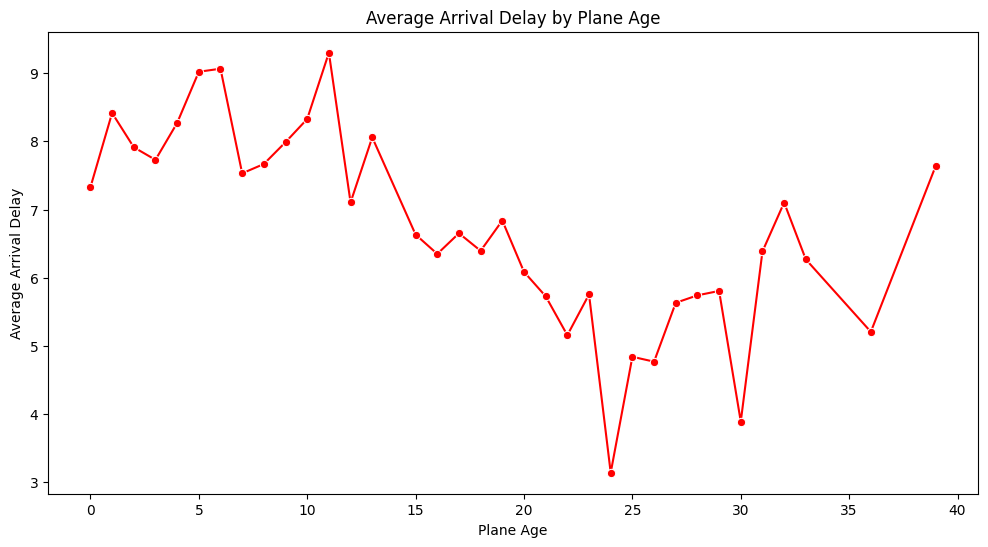

In [27]:
#plotting a line graph to show the relationship between plane age and average total delay
plt.figure(figsize=(12, 6))
sns.lineplot(data=plane_age_groups, x='plane_age', y='average_arrdelay', marker='o', color='red')

# Labels and title
plt.xlabel("Plane Age")
plt.ylabel("Average Arrival Delay")
plt.title("Average Arrival Delay by Plane Age")

# Display the plot
plt.show()


Based on the graph above, from age 0 to 24, the general trend of delays against plane age is decreasing, meaning as age increases, delay decreases. However, after the age of 24, delay is generally increasing as age increases.

Plotting a scatterplot to show general trend of the dataset

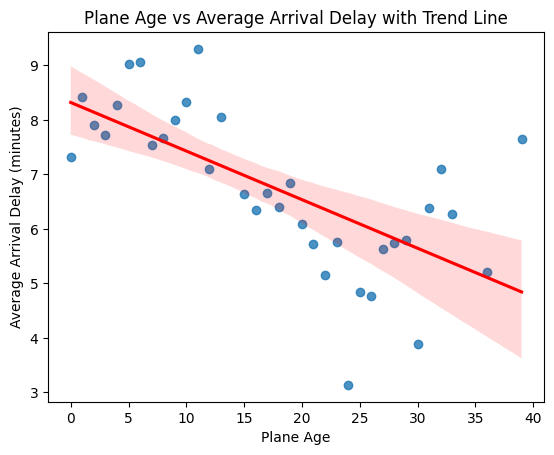

In [38]:
# Scatterplot with regression (trend) line
sns.regplot(data=plane_age_groups, x='plane_age', y='average_arrdelay', scatter=True, line_kws={"color": "red"})

# Title and Labels
plt.title("Plane Age vs Average Arrival Delay with Trend Line")
plt.xlabel("Plane Age")
plt.ylabel("Average Arrival Delay (minutes)")
plt.show()


We will now be plotting a correlation matrix to confirm our findings.

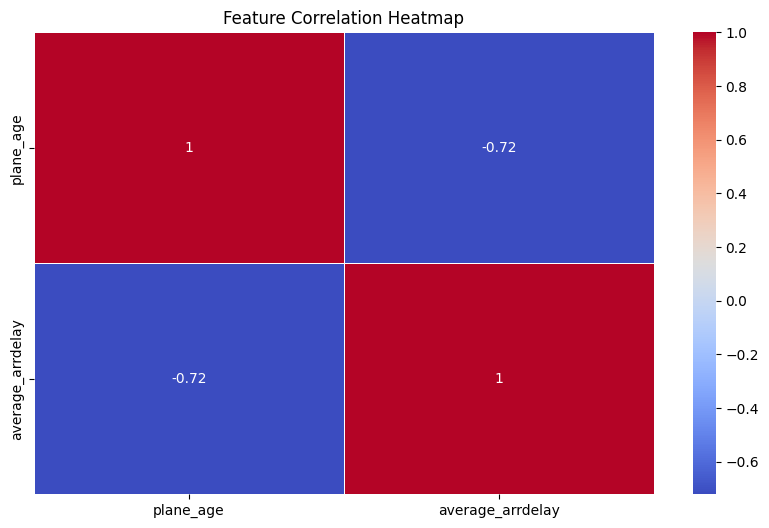

In [29]:
# Compute the correlation matrix
corr_matrix = plane_age_groups.corr(method='spearman') #since relationship of plane age and average arrival delay is not linear, use spearman correlation matrix

# Create a heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', linewidths=0.5)

# Title
plt.title("Feature Correlation Heatmap")

# Show plot
plt.show()


This shows that plane age has a negative correlation between arrival delays, which supports the graphs above, where as plane age increases, delays generally decrease. 


# Trend throughout the years.

We will first group the dataset by its years.

In [39]:
# Create a dictionary to store the yearly DataFrames
yearly_age_dfs = {}

# Loop through the years and create a filtered DataFrame for each
for year in range(1995, 2000): 
    yearly_age_dfs[year] = age_df[age_df['current_year'] == year]


Grouping dataset by tail number

In [40]:
# Dictionary to store summary DataFrames for each year
yearly_plane_summaries = {}

# Loop through each year's DataFrame
for year, df in yearly_age_dfs.items():
    summary = df.groupby('tailnum', as_index=False).agg(
        average_arrdelay=('arrdelay', 'mean'),
        plane_age=('plane_age', 'first')
    )
    yearly_plane_summaries[year] = summary


Removing plane age that are less than 0

In [46]:
for year in yearly_plane_summaries:
    yearly_plane_summaries[year] = yearly_plane_summaries[year][yearly_plane_summaries[year]['plane_age'] >= 0]


Grouping the dataset by its plane age

In [47]:
# Dictionary to store grouped-by-age DataFrames
yearly_age_groups = {}

for year, df in yearly_plane_summaries.items():
    grouped = df.groupby('plane_age', as_index=False).agg(
        average_arrdelay=('average_arrdelay', 'mean')
    )
    yearly_age_groups[year] = grouped

Plotting correlation heatmap for each year.

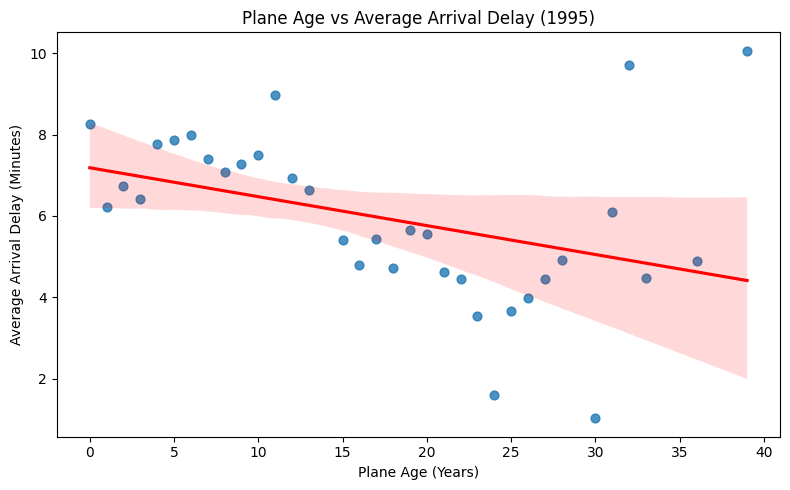

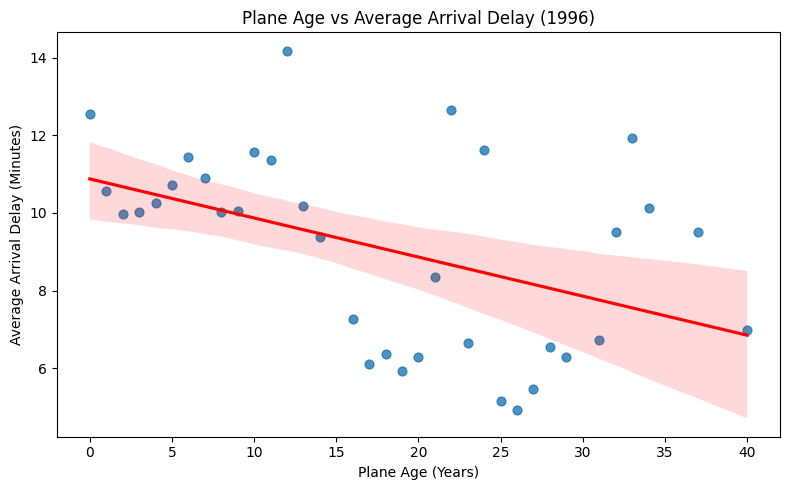

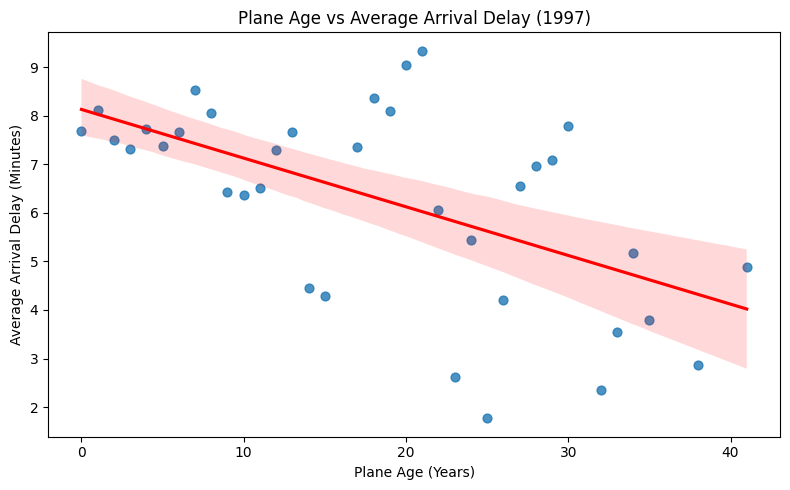

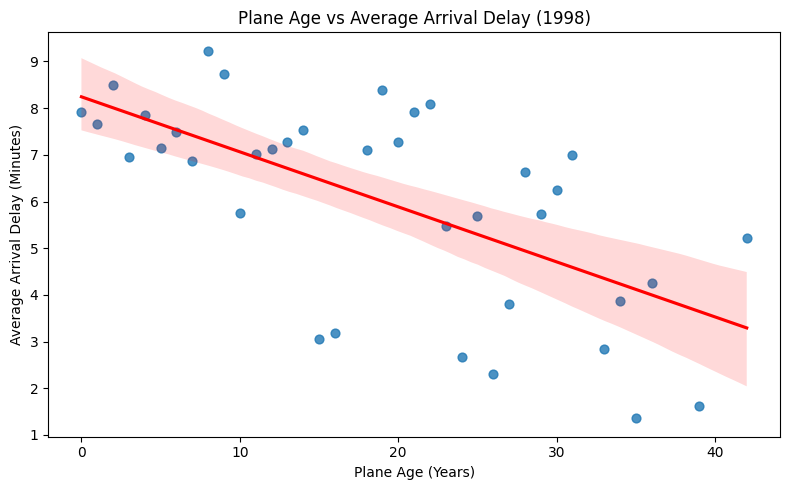

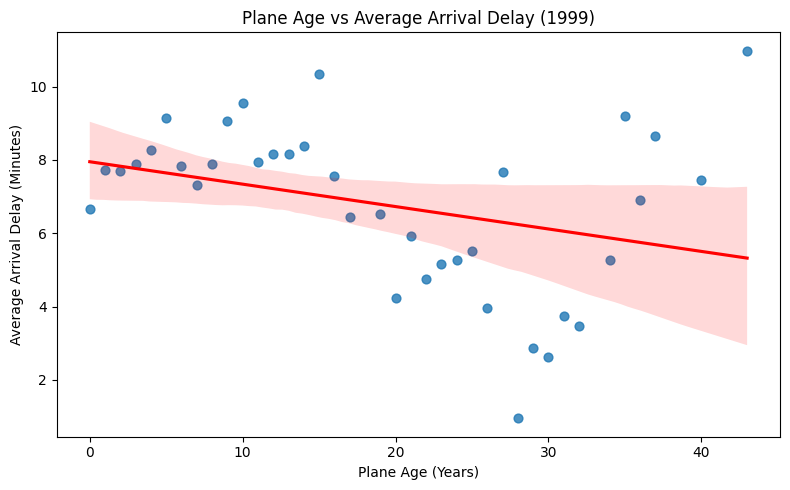

In [48]:
# Plot correlation for each year
for year, df in yearly_age_groups.items():
    plt.figure(figsize=(8, 5))
    sns.regplot(data=df, x='plane_age', y='average_arrdelay', scatter_kws={'s': 40}, line_kws={'color': 'red'})
    plt.title(f'Plane Age vs Average Arrival Delay ({year})')
    plt.xlabel('Plane Age (Years)')
    plt.ylabel('Average Arrival Delay (Minutes)')
    plt.tight_layout()
    plt.show()


The general trend for plane age vs average arrival delay is generally decreasing throughout the years. 

Plotting correlation heatmap throughout the years

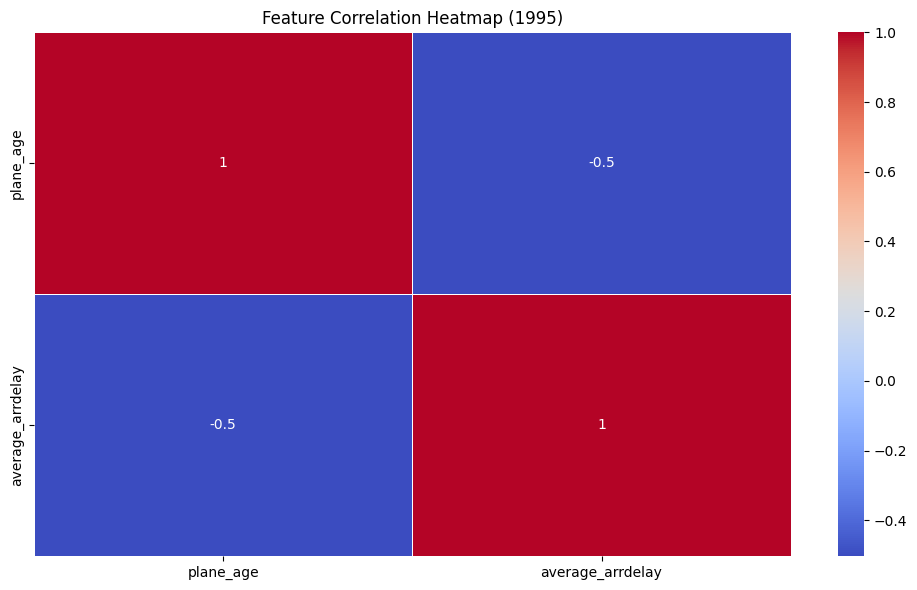

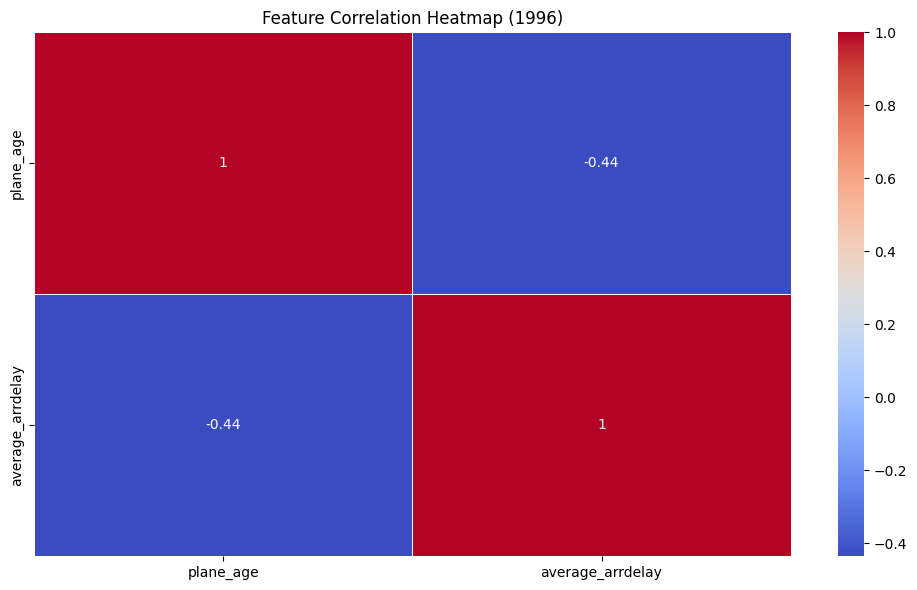

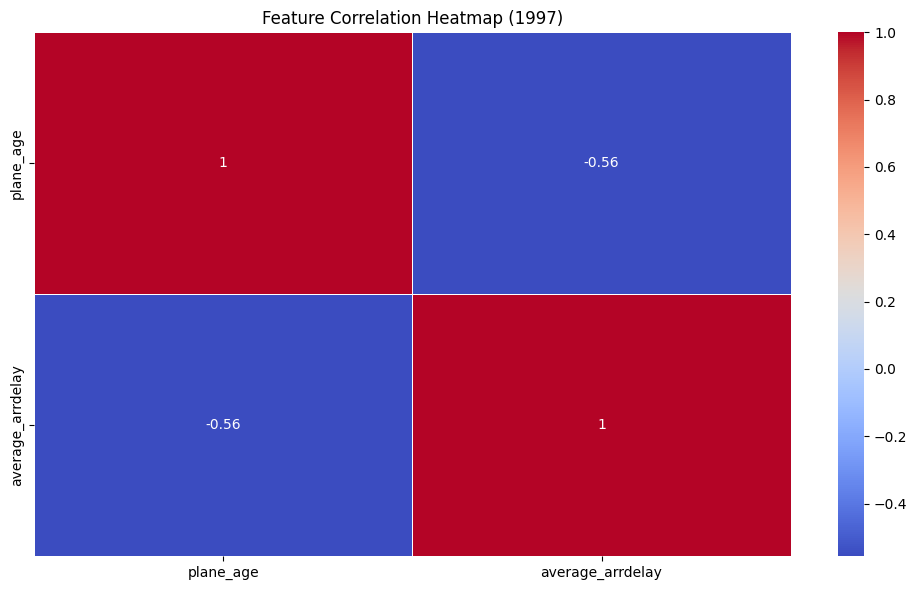

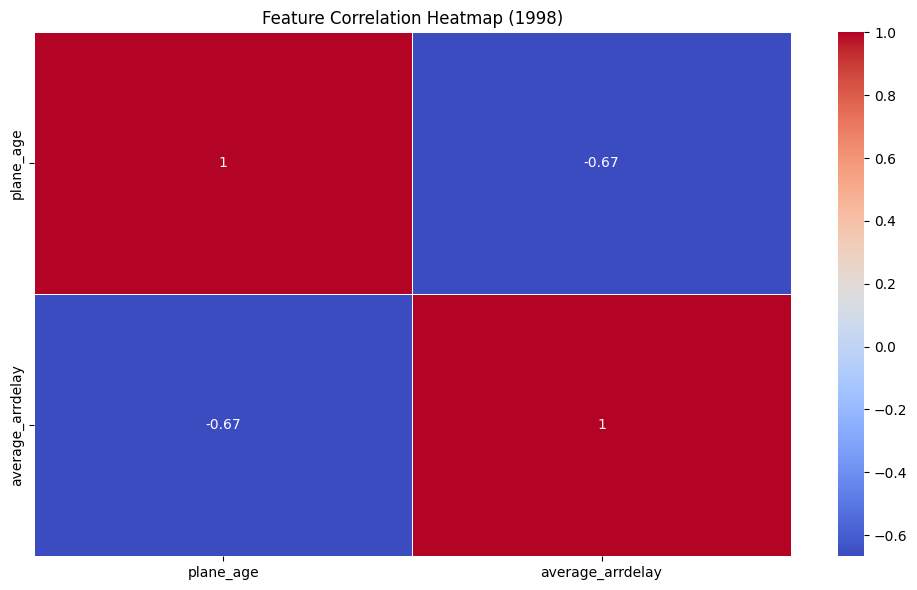

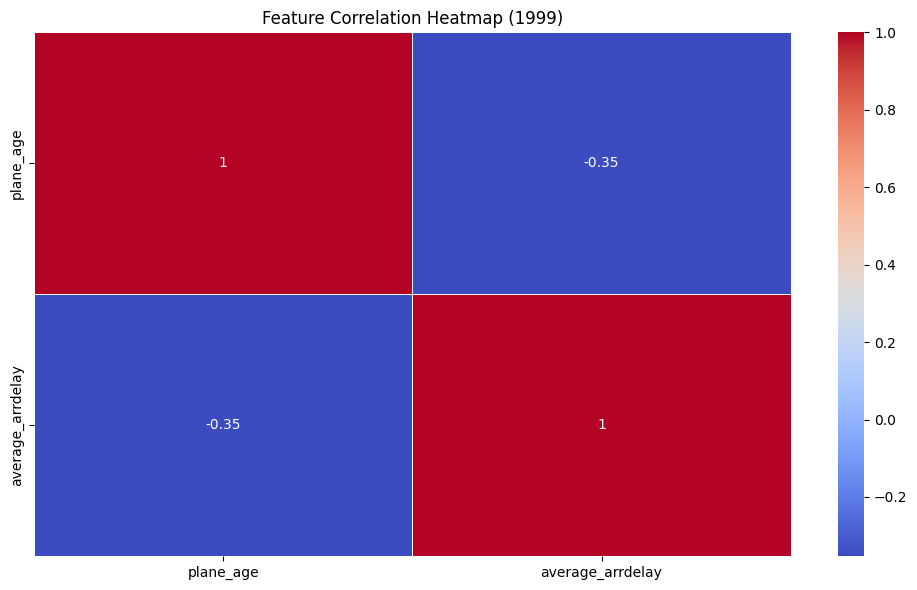

In [50]:
for year, df in yearly_age_groups.items():
    # Compute Spearman correlation matrix
    corr_matrix = df.corr(method='spearman')
    
    # Plot heatmap
    plt.figure(figsize=(10, 6))
    sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', linewidths=0.5)
    plt.title(f"Feature Correlation Heatmap ({year})")
    plt.tight_layout()
    plt.show()



These heatmaps support the earlier visual observations that the trend between plane age and average arrival delay is generally downward. In 1995, 1996, and 1997, the Spearman correlation between plane age and average arrival delay ranges from -0.44 to -0.56, indicating a moderate negative correlation. In contrast, 1998 shows a stronger negative correlation of -0.67, while 1999 shows a weaker negative correlation of -0.35, indicating that the relationship varied slightly from year to year but remained consistently negative across the five-year period. This suggests that older aircraft were associated with lower average arrival delays during these years.


Reasons why this might be the case:

- newer planes being assigned to longer and more complicated routes while older planes being assigned to shorter and simpler routes, leading to newer planes having more delays compared to older planes

- older planes may be used much lesser than newer planes, leading to more instances of delays for newer planes

- there may be a survivorship bias as the older planes still flying are more reliable than the newer ones. 

# Part 2(c) Logistic Regression for the probability of diverted US flights

Data cleaning


We will be first be removing cancelled flights as cancelled flights can't be diverted.

In [53]:
diverted_df = main_df.copy()
diverted_df = diverted_df[diverted_df['cancelled'] == 0]
print(diverted_df['cancelled'].value_counts())

cancelled
0    26375085
Name: count, dtype: int64


In [54]:
diverted_df.head()

,year,month,dayofmonth,dayofweek,deptime,crsdeptime,arrtime,crsarrtime,uniquecarrier,flightnum,...,taxiin,taxiout,cancelled,cancellationcode,diverted,carrierdelay,weatherdelay,nasdelay,securitydelay,lateaircraftdelay
0,1995,1,6,5,657.0,645,952.0,937,UA,482,...,7,25,0,NaN,0,NaN,NaN,NaN,NaN,NaN
1,1995,1,7,6,648.0,645,938.0,937,UA,482,...,5,17,0,NaN,0,NaN,NaN,NaN,NaN,NaN
2,1995,1,8,7,649.0,645,932.0,937,UA,482,...,3,17,0,NaN,0,NaN,NaN,NaN,NaN,NaN
3,1995,1,9,1,645.0,645,928.0,937,UA,482,...,3,16,0,NaN,0,NaN,NaN,NaN,NaN,NaN
4,1995,1,10,2,645.0,645,931.0,937,UA,482,...,6,18,0,NaN,0,NaN,NaN,NaN,NaN,NaN


Removing null values in columns that we will be using for logistic regression.

In [55]:
print(diverted_df.isnull().sum())

year                        0
month                       0
dayofmonth                  0
dayofweek                   0
deptime                     0
crsdeptime                  0
arrtime                 63397
crsarrtime                  0
uniquecarrier               0
flightnum                   0
tailnum                     0
actualelapsedtime       63397
crselapsedtime           1771
airtime                 63397
arrdelay                63397
depdelay                    0
origin                      0
dest                        0
distance                 5908
taxiin                      0
taxiout                     0
cancelled                   0
cancellationcode     26375085
diverted                    0
carrierdelay         26375085
weatherdelay         26375085
nasdelay             26375085
securitydelay        26375085
lateaircraftdelay    26375085
dtype: int64


We will now be removing null values from features and target columns. 

In [64]:
features = ['month', 'dayofmonth', 'dayofweek', 'crsdeptime', 'crsarrtime', 'distance', 
            'uniquecarrier', 'origin', 'dest', 'depdelay', 'taxiout']

target = ['diverted']

diverted_df = diverted_df.dropna(subset=features + target)
print(diverted_df.isnull().sum())

year                        0
month                       0
dayofmonth                  0
dayofweek                   0
deptime                     0
crsdeptime                  0
arrtime                 63384
crsarrtime                  0
uniquecarrier               0
flightnum                   0
tailnum                     0
actualelapsedtime       63384
crselapsedtime           1771
airtime                 63384
arrdelay                63384
depdelay                    0
origin                      0
dest                        0
distance                    0
taxiin                      0
taxiout                     0
cancelled                   0
cancellationcode     26369177
diverted                    0
carrierdelay         26369177
weatherdelay         26369177
nasdelay             26369177
securitydelay        26369177
lateaircraftdelay    26369177
dtype: int64


We will be first checking for perfect multicollinearity to identify and remove redundant variables.

In [58]:
# Selecting numerical features from our selected features for correlation analysis
numerical_variables = ['month', 'dayofmonth', 'dayofweek', 'crsdeptime', 'crsarrtime', 'distance', 'depdelay', 'taxiout']

print(diverted_df[numerical_variables].isnull().sum())

month         0
dayofmonth    0
dayofweek     0
crsdeptime    0
crsarrtime    0
distance      0
depdelay      0
taxiout       0
dtype: int64


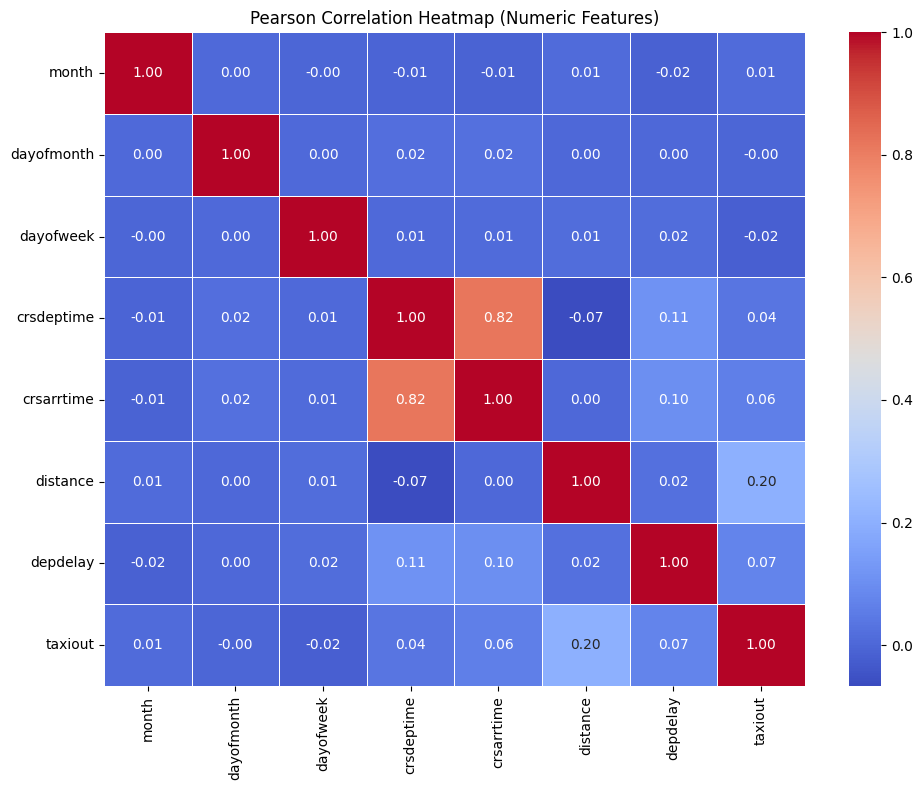

In [59]:
# Assigning numerical variables to corr_df
corr_df = diverted_df[numerical_variables].copy()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_df.corr(method='pearson'), annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title("Pearson Correlation Heatmap (Numeric Features)")
plt.tight_layout()
plt.show()

Since there is no pairwise correlation that is equal to one, the assumption of no perfect multicollinearity is satisfied. However, we will be removing dayofmonth as it has very low correlation and has low predictive value. 

# Logistic Regression Analysis throughout the years


We will first be splitting our features into categorical and numerical features

In [66]:
cat_features = ['month', 'dayofweek', 'uniquecarrier', 'origin', 'dest']
num_features = ['crsdeptime', 'crsarrtime', 'distance', 'depdelay', 'taxiout']
target = 'diverted'

Using a for loop, cycle throughout the years and apply logistic regeression to it


--- Year 1995 ---
              precision    recall  f1-score   support

Not Diverted       1.00      0.72      0.83   1565152
    Diverted       0.00      0.63      0.01      3143

    accuracy                           0.72   1568295
   macro avg       0.50      0.67      0.42   1568295
weighted avg       1.00      0.72      0.83   1568295

Accuracy: 0.7153877299870242
F1 Score: 0.0087982270306761


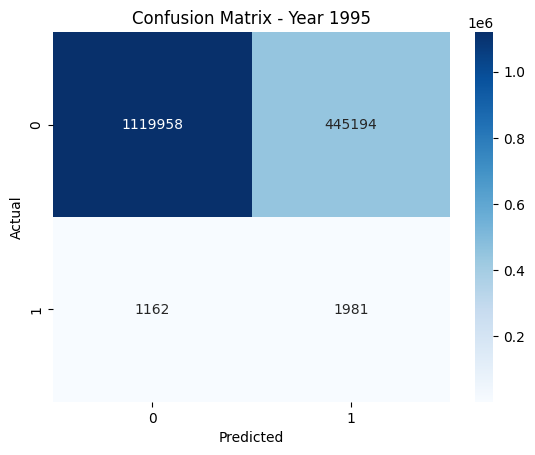

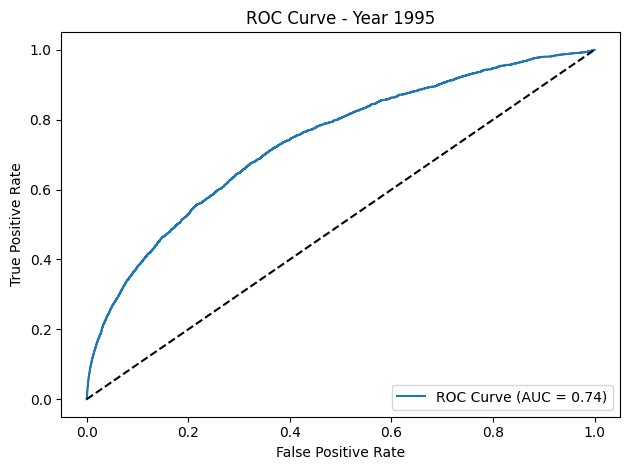


--- Year 1996 ---
              precision    recall  f1-score   support

Not Diverted       1.00      0.72      0.84   1562140
    Diverted       0.01      0.65      0.01      4236

    accuracy                           0.72   1566376
   macro avg       0.50      0.68      0.42   1566376
weighted avg       1.00      0.72      0.83   1566376

Accuracy: 0.7189882888910453
F1 Score: 0.012340969775843112


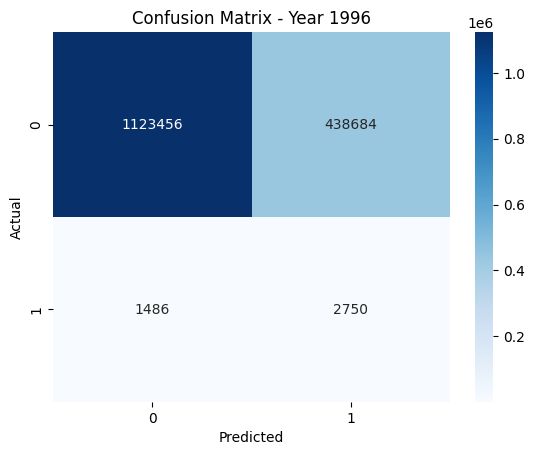

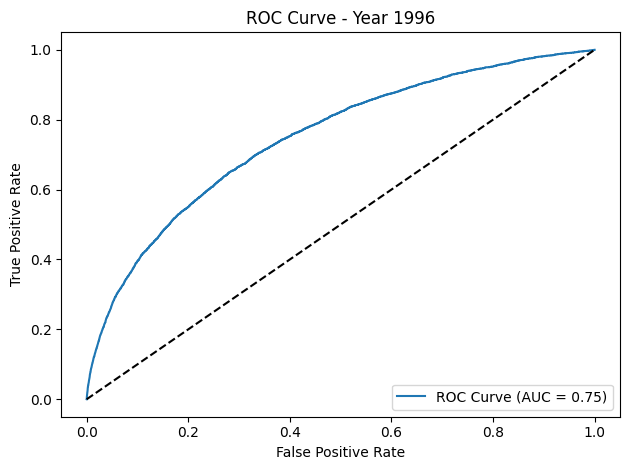


--- Year 1997 ---
              precision    recall  f1-score   support

Not Diverted       1.00      0.70      0.83   1589877
    Diverted       0.01      0.68      0.01      3624

    accuracy                           0.70   1593501
   macro avg       0.50      0.69      0.42   1593501
weighted avg       1.00      0.70      0.82   1593501

Accuracy: 0.7036876663397136
F1 Score: 0.010378809790286004


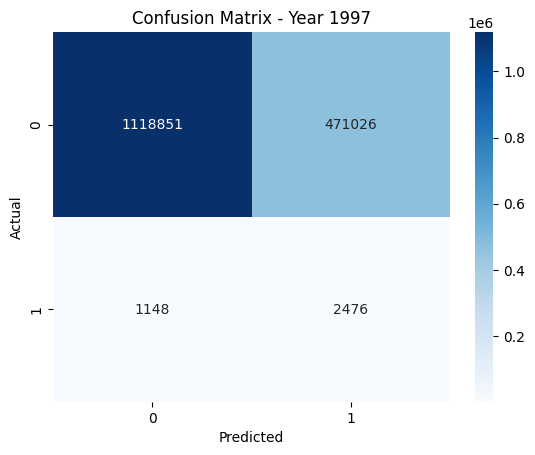

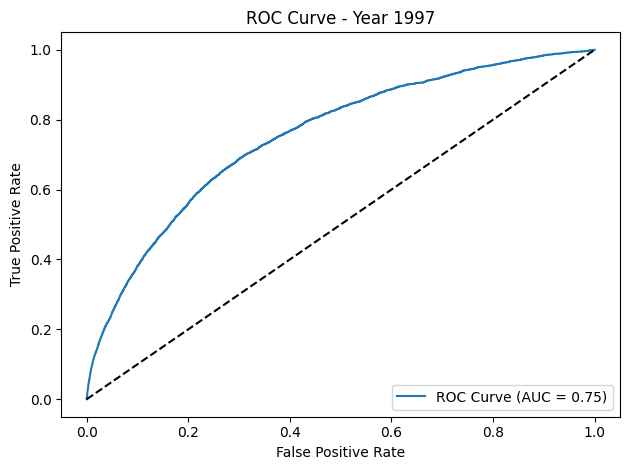


--- Year 1998 ---
              precision    recall  f1-score   support

Not Diverted       1.00      0.72      0.84   1567361
    Diverted       0.01      0.65      0.01      3947

    accuracy                           0.72   1571308
   macro avg       0.50      0.69      0.42   1571308
weighted avg       1.00      0.72      0.84   1571308

Accuracy: 0.7210884180568037
F1 Score: 0.01157005408380057


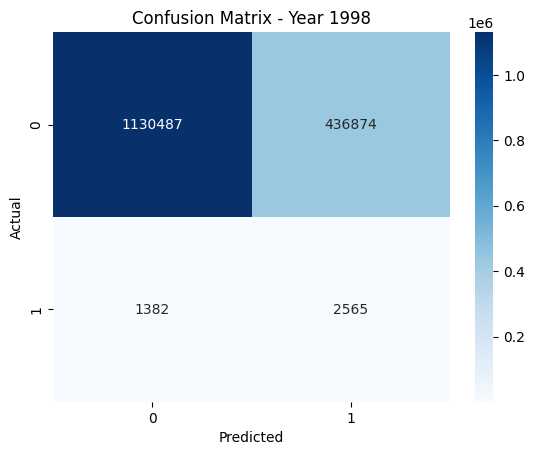

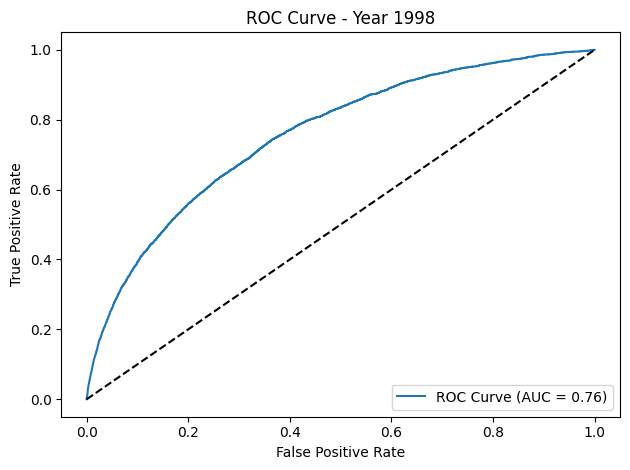


--- Year 1999 ---
              precision    recall  f1-score   support

Not Diverted       1.00      0.71      0.83   1607209
    Diverted       0.01      0.67      0.01      4066

    accuracy                           0.71   1611275
   macro avg       0.50      0.69      0.42   1611275
weighted avg       1.00      0.71      0.83   1611275

Accuracy: 0.7137831841243736
F1 Score: 0.011700819057334014


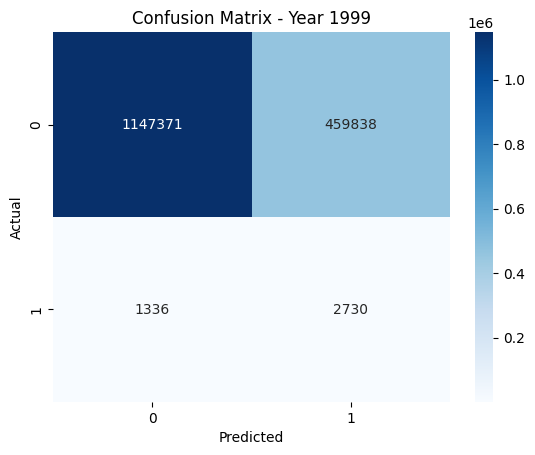

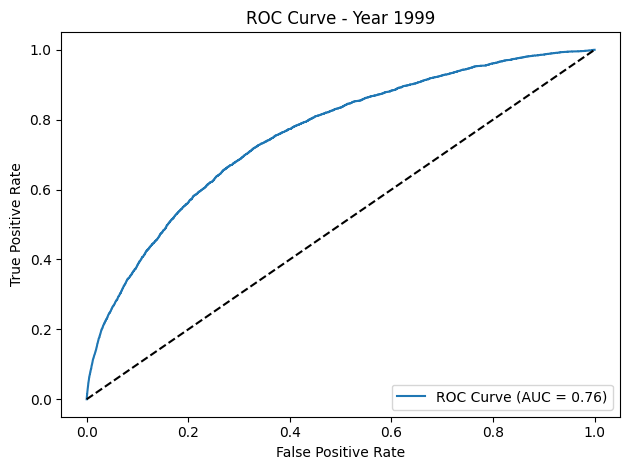

In [76]:
# Create empty list to store coefficients for each year 
coeffs = []

for year in sorted(diverted_df['year'].unique()):
    
    # Making sure there's no missing values in the features and target
    df_year = diverted_df[diverted_df['year'] == year].dropna(subset=features + [target]) 
    X = df_year[features]
    y = df_year[target].astype(int)

    # Train/test split with stratification, which ensures that the target variable is evenly distributed in both sets
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, stratify=y, random_state=42) #splitting the data into 70% training and 30% testing

    # Preprocessing pipeline
    preprocessor = ColumnTransformer([('num', StandardScaler(), num_features),('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), cat_features)])

    # Logistic Regression pipeline
    model = Pipeline(steps=[('preprocessor', preprocessor),('classifier', LogisticRegression(max_iter=1000, class_weight='balanced'))])
    model.fit(X_train, y_train)

    # Predict and evaluate the model using confusion matrix, accuracy score and F1 score.
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]

    # Classification report and accuracy score
    print(f"\n--- Year {year} ---")
    print(classification_report(y_test, y_pred, target_names=['Not Diverted', 'Diverted']))
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print("F1 Score:", f1_score(y_test, y_pred))

    # Confusion matrix
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f"Confusion Matrix - Year {year}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

    # ROC Curve
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    roc_auc = auc(fpr, tpr)

    plt.figure()
    plt.plot(fpr, tpr, label=f'ROC Curve (AUC = {roc_auc:.2f})')
    plt.plot([0, 1], [0, 1], 'k--')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(f'ROC Curve - Year {year}')
    plt.legend(loc='lower right')
    plt.tight_layout()
    plt.show()

    # Save coefficients to plot a graph later
    feature_names = model.named_steps['preprocessor'].get_feature_names_out()
    coef_values = model.named_steps['classifier'].coef_[0]

    coef_df = pd.DataFrame({
        'feature': feature_names,
        'coefficient': coef_values,
        'year': year
    })
    
    coeffs.append(coef_df)

Visualizing yearly logistic regression coefficients over time 

In [78]:
# List all unique feature names available in the coefficient DataFrame
print(coef_df['feature'].unique())


['num__crsdeptime' 'num__crsarrtime' 'num__distance' 'num__depdelay'
 'num__taxiout' 'cat__month_2' 'cat__month_3' 'cat__month_4'
 'cat__month_5' 'cat__month_6' 'cat__month_7' 'cat__month_8'
 'cat__month_9' 'cat__month_10' 'cat__month_11' 'cat__month_12'
 'cat__dayofweek_2' 'cat__dayofweek_3' 'cat__dayofweek_4'
 'cat__dayofweek_5' 'cat__dayofweek_6' 'cat__dayofweek_7'
 'cat__uniquecarrier_AS' 'cat__uniquecarrier_CO' 'cat__uniquecarrier_DL'
 'cat__uniquecarrier_HP' 'cat__uniquecarrier_NW' 'cat__uniquecarrier_TW'
 'cat__uniquecarrier_UA' 'cat__uniquecarrier_US' 'cat__uniquecarrier_WN'
 'cat__origin_ABQ' 'cat__origin_ADQ' 'cat__origin_AGS' 'cat__origin_AKN'
 'cat__origin_ALB' 'cat__origin_AMA' 'cat__origin_ANC' 'cat__origin_ATL'
 'cat__origin_AUS' 'cat__origin_AVL' 'cat__origin_AVP' 'cat__origin_AZO'
 'cat__origin_BDL' 'cat__origin_BET' 'cat__origin_BFL' 'cat__origin_BGM'
 'cat__origin_BGR' 'cat__origin_BHM' 'cat__origin_BIL' 'cat__origin_BIS'
 'cat__origin_BNA' 'cat__origin_BOI' 'cat__or

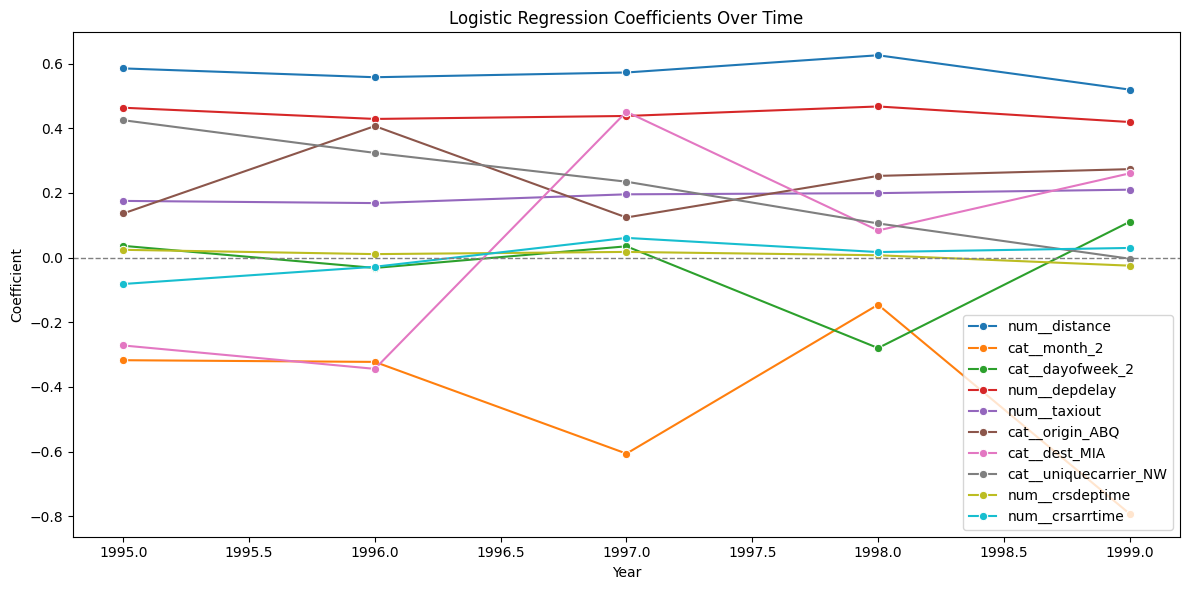

In [79]:
coeffs_df = pd.concat(coeffs)

# Choose key features to visualize
features_to_plot = ['num__distance', 'cat__month_2', 'cat__dayofweek_2', 'num__depdelay', 'num__taxiout', 'cat__origin_ABQ', 'cat__dest_MIA','cat__uniquecarrier_NW','num__crsdeptime','num__crsarrtime']

plt.figure(figsize=(12, 6))

for f in features_to_plot:
    subset = coeffs_df[coeffs_df['feature'] == f]
    sns.lineplot(data=subset, x='year', y='coefficient', label=f, marker='o')  # add markers

# Reference line at y=0
plt.axhline(0, color='gray', linestyle='--', linewidth=1)

# Titles and labels
plt.title("Logistic Regression Coefficients Over Time")
plt.ylabel("Coefficient")
plt.xlabel("Year")
plt.legend()
plt.tight_layout()
plt.show()


From the graphs and values above, we can see how the influence of different flight attributes on diversion probability evolves year to year. Features like distance and depdelay have consistent, strong positive effects, while others like month_2 and dayofweek_2 vary more in strength and direction.

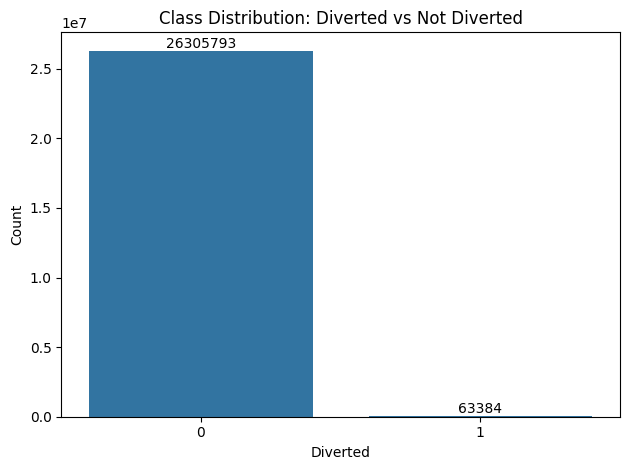

In [102]:
sns.countplot(x=diverted_df['diverted'])
plt.title("Class Distribution: Diverted vs Not Diverted")
plt.xlabel("Diverted")
plt.ylabel("Count")

# Add value labels on top of each bar
counts = diverted_df['diverted'].value_counts()
for i, count in enumerate(counts):
    plt.text(i, count + 5000, str(count), ha='center', va='bottom')

plt.tight_layout()
plt.show()


As we can see, there is very little diverted compared to non-diverted flights in our dataset, which is causing our precision of our model to be extremely low for predicting diverted flights.  

Hence, the model can be improved using resampling techniques for imbalanced data, such as SMOTE or random oversampling. SMOTE, which stands for Synthetic Minority Over-sampling Technique generates fake examples by interpolating between existing minority class samples. Random Oversampling on the other hand duplicates examples from the minority class. Both these examples help to address the class imbalance and thus, would obtain a better precision score. 
